In [1]:
# simulate a random walk in 1800D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path_figs = "./Figs/RandomWalk/"


In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker

def set_figure_style(scale="1col"):
    """
    Set figure styling based on publication constraints.
    
    Parameters:
        scale (str): Scale of the figure, choose from "1col", "1.5col", "2col".
                     - "1col" for 8.5cm
                     - "1.5col" for 11.6cm
                     - "2col" for 17.6cm
    """
    # Define width options in cm
    widths = {"1col": 7.62, "1.5col": 11.6, "2col": 16.5}
    
    if scale not in widths:
        raise ValueError("Invalid scale. Choose from '1col', '1.5col', or '2col'.")
    
    # Convert width from cm to inches (1 cm = 0.393701 inches)
    width_in = widths[scale] * 0.393701
    
    # Set figure size (width, height)
    # Assuming height proportional to width (Golden Ratio)
    golden_ratio = (5**0.5 - 1) / 2
    rcParams["figure.figsize"] = (width_in, width_in * golden_ratio)
    
    # Set font sizes
    rcParams["font.size"] = 10  # General font size
    # rcParams["font.size"] = 20  # General font size
    rcParams["axes.titlesize"] = 12  # Figure title
    # rcParams["axes.titlesize"] = 26  # Figure title
    rcParams["axes.labelsize"] = 9  # Axis main label
    # rcParams["axes.labelsize"] = 22  # Axis main label
    rcParams["xtick.labelsize"] = 7  # Tick labels
    # rcParams["xtick.labelsize"] = 16  # Tick labels
    rcParams["ytick.labelsize"] = 7
    # rcParams["ytick.labelsize"] = 16
    rcParams["legend.fontsize"] = 8  # Legend entries
    # rcParams["legend.fontsize"] = 20  # Legend entries
    rcParams["figure.titleweight"] = "bold"
    
    # Set stroke width
    rcParams["axes.linewidth"] = 0.75
    # rcParams["axes.linewidth"] = 1.5

    # rcParams["lines.linewidth"] = 3
    
    rcParams["xtick.major.width"] = 0.75
    # rcParams["xtick.major.width"] = 1.5
    rcParams["ytick.major.width"] = 0.75
    # rcParams["ytick.major.width"] = 1.5

    
    # Subpanel lettering size
    rcParams["text.usetex"] = False  # Set to True if using LaTeX
    rcParams["axes.formatter.use_mathtext"] = True  # Math text for scientific notation

def add_subpanel_label(ax, label, fontsize=20, position=(-0.1, 1.05)):
    """
    Add a subpanel label (e.g., 'a', 'b') to a subplot.
    
    Parameters:
        ax (Axes): Matplotlib Axes object.
        label (str): The label text.
        fontsize (int): Font size for the label.
        position (tuple): Position of the label in axes coordinates.
    """
    ax.text(position[0], position[1], label, transform=ax.transAxes, 
            fontsize=fontsize, fontweight="bold", va="top", ha="left")

###
set_figure_style(scale="1col")

sns.set_palette("colorblind")


In [5]:
D = 1800
n_steps = 640
def random_walk(D, n_steps):
    steps = np.random.randn(n_steps, D) * 0.1
    return np.cumsum(steps, axis=0)

In [296]:
data = random_walk(D, n_steps)

data = pd.DataFrame(data)
data['N'] = np.arange(n_steps)
X = data.to_numpy()[:,:-1]
trials = data['N'].to_numpy()
n = len(trials)
i,j = np.triu_indices(n, k=1)
# calculate pairwise distances
distances = np.linalg.norm(X[i] - X[j], axis=1)
trial_distances = np.abs(trials[i] - trials[j])
df = pd.DataFrame({'trial1': trials[i], 'trial2': trials[j], 'distance': distances, 'trial_distance': trial_distances})


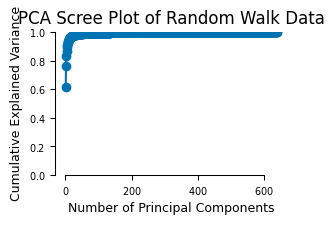

In [297]:
# plot scree plot of data (cumulative explained variance)
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
plt.figure()
plt.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot of Random Walk Data')
plt.ylim(0,1)
sns.despine(trim=True)


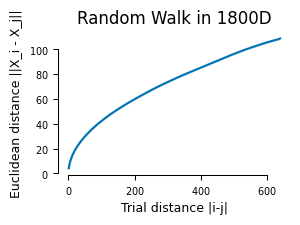

In [299]:
sns.lineplot(data=df, x='trial_distance', y='distance')
plt.xlabel('Trial distance |i-j|')
plt.ylabel('Euclidean distance ||X_i - X_j||')
plt.title('Random Walk in 1800D')
sns.despine(trim=True)
plt.savefig(path_figs + 'random_walk_1800D.pdf', dpi=300, bbox_inches='tight')


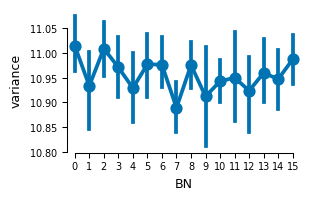

In [301]:
n_sims = 10
n_trials_per_block = 40
n_blocks = n_steps // n_trials_per_block
all_data = []
for sim in range(n_sims):
    data_damped = random_walk(D, n_steps)
    data = pd.DataFrame(data_damped, columns=[f'Force{i+1}' for i in range(data_damped.shape[1])])
    blocks = np.repeat(np.arange(n_blocks), n_trials_per_block)
    if len(blocks) < n_steps:
        blocks = np.append(blocks, np.full(n_steps - len(blocks), n_blocks))
    data['block'] = blocks
    data['sim'] = sim
    all_data.append(data)
data = pd.concat(all_data, ignore_index=True)


data['force_vector'] = data[[f'Force{i+1}' for i in range(D)]].values.tolist()

variability_trends = []
for sim, simdata in data.groupby('sim'):
     for block, blockdata in simdata.groupby('block'):
        forces = np.array(blockdata['force_vector'].tolist())
        mean_force = np.mean(forces, axis=0)
        var = np.sqrt(((forces - mean_force) ** 2).sum(axis = 1).mean())
        variability_trends.append({
            'BN': block,
            'variance': var,
            'sim': sim
        })
variability_trends = pd.DataFrame(variability_trends)
sns.pointplot(data=variability_trends, x='BN', y='variance')
sns.despine(trim=True)
# plt.savefig('random_walk_variability_trend.pdf', dpi=300, bbox_inches='tight')
    


<Axes: >

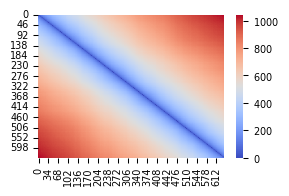

In [5]:
distances = np.linalg.norm((X[np.newaxis, :, :] - X[:, np.newaxis, :]), axis=-1)  # shape (n, n)
sns.heatmap(distances, cmap='coolwarm')

<Axes: >

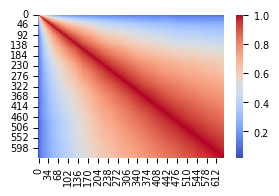

In [7]:
cosine_sims = X @ X.T / (np.linalg.norm(X, axis=1, keepdims=True) @ np.linalg.norm(X, axis=1, keepdims=True).T)
sns.heatmap(cosine_sims, cmap='coolwarm')

In [3]:
def random_walk_damped(D, n_steps, alpha, step_scale=1.0, init = None):
    steps = np.random.randn(n_steps, D) * step_scale
    X = np.empty((n_steps, D))
    if init is not None:
        X[0] = init
    else:
        X[0] = steps[0]
    for t in range(1, n_steps):
        X[t] = alpha * X[t-1] + steps[t]
    return X

In [15]:
data_damped = random_walk_damped(D, n_steps, alpha=0.999)
# print(data_damped)

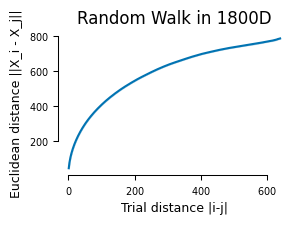

In [244]:
data = pd.DataFrame(data_damped, columns=[f'Force{i+1}' for i in range(data_damped.shape[1])])
data['N'] = np.arange(n_steps)
X = data.to_numpy()[:,:-1]
trials = data['N'].to_numpy()
n = len(trials)
i,j = np.triu_indices(n, k=1)
# calculate pairwise distances
distances = np.linalg.norm(X[i] - X[j], axis=1)
trial_distances = np.abs(trials[i] - trials[j])
df = pd.DataFrame({'trial1': trials[i], 'trial2': trials[j], 'distance': distances, 'trial_distance': trial_distances})

sns.lineplot(data=df, x='trial_distance', y='distance')
plt.xlabel('Trial distance |i-j|')
plt.ylabel('Euclidean distance ||X_i - X_j||')
plt.title('Random Walk in 1800D')
sns.despine(trim=True)
# plt.savefig('random_walk_damped_1800D.pdf', dpi=300, bbox_inches='tight')


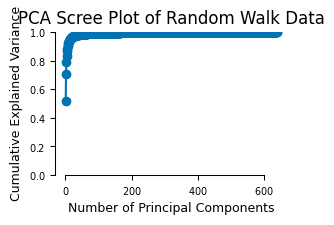

In [181]:
# plot scree plot of data (cumulative explained variance)
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(data_damped)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
plt.figure()
plt.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot of Random Walk Data')
plt.ylim(0,1)
sns.despine(trim=True)

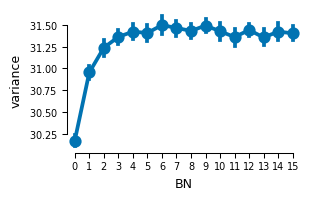

In [161]:
alpha = 0.99
step_scale = 0.3
init = np.ones(D) * 0

n_sims = 50
n_trials_per_block = 40
n_blocks = n_steps // n_trials_per_block
all_data = []
for sim in range(n_sims):
    data_damped = random_walk_damped(D, n_steps, alpha = alpha, step_scale=step_scale, init = init)
    data = pd.DataFrame(data_damped, columns=[f'Force{i+1}' for i in range(data_damped.shape[1])])
    blocks = np.repeat(np.arange(n_blocks), n_trials_per_block)
    if len(blocks) < n_steps:
        blocks = np.append(blocks, np.full(n_steps - len(blocks), n_blocks))
    data['block'] = blocks
    data['sim'] = sim
    all_data.append(data)
data = pd.concat(all_data, ignore_index=True)


data['force_vector'] = data[[f'Force{i+1}' for i in range(D)]].values.tolist()

variability_trends = []
for sim, simdata in data.groupby('sim'):
     for block, blockdata in simdata.groupby('block'):
        forces = np.array(blockdata['force_vector'].tolist())
        mean_force = np.mean(forces, axis=0)
        var = np.sqrt(((forces - mean_force) ** 2).sum(axis = 1).mean())
        variability_trends.append({
            'BN': block,
            'variance': var,
            'sim': sim
        })
variability_trends = pd.DataFrame(variability_trends)
sns.pointplot(data=variability_trends, x='BN', y='variance')
sns.despine(trim=True)
plt.savefig('random_walk_variability_trend.pdf', dpi=300, bbox_inches='tight')
    


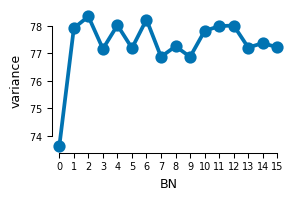

In [188]:
data = pd.DataFrame(data_damped, columns=[f'Force{i+1}' for i in range(data_damped.shape[1])])
data['force_vector'] = data[[f'Force{i+1}' for i in range(D)]].values.tolist()

variability_trends = []
n_trials_per_block = 40
# divide consequtive trials to blocks 
n_blocks = n_steps // n_trials_per_block
blocks = np.repeat(np.arange(n_blocks), n_trials_per_block)
if len(blocks) < n_steps:
    blocks = np.append(blocks, np.full(n_steps - len(blocks), n_blocks))
data['block'] = blocks

for block, blockdata in data.groupby('block'):
    forces = np.array(blockdata['force_vector'].tolist())
    mean_force = np.mean(forces, axis=0)
    var = np.sqrt(((forces - mean_force) ** 2).sum(axis = 1).mean())
    variability_trends.append({
        'BN': block,
        'variance': var
    })
variability_trends = pd.DataFrame(variability_trends)
sns.pointplot(data=variability_trends, x='BN', y='variance')
sns.despine(trim=True)
plt.savefig('random_walk_variability_trend.pdf', dpi=300, bbox_inches='tight')
    


/var/folders/wg/16zn32014z5grhdv06dk49f00000gn/T/ipykernel_64200/3212477973.py:4: RuntimeWarning: invalid value encountered in divide
  cosine_sims = forces @ forces.T / (np.linalg.norm(forces, axis=1, keepdims=True) @ np.linalg.norm(forces, axis=1, keepdims=True).T)


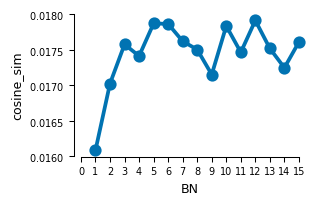

In [162]:
cos_sim_trends = []
for block, blockdata in data.groupby('block'):
    forces = np.array(blockdata['force_vector'].tolist())
    cosine_sims = forces @ forces.T / (np.linalg.norm(forces, axis=1, keepdims=True) @ np.linalg.norm(forces, axis=1, keepdims=True).T)
    i,j = np.triu_indices(cosine_sims.shape[0], k=1)
    sims = cosine_sims[i,j]
    mean_sims = np.mean(sims)
    cos_sim_trends.append({
        'BN': block,
        'cosine_sim': mean_sims
    })
cos_sim_trends = pd.DataFrame(cos_sim_trends)
sns.pointplot(data=cos_sim_trends, x='BN', y='cosine_sim')
sns.despine(trim=True)


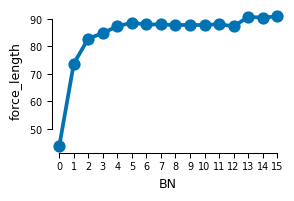

In [42]:
force_length_trends = []
for block, blockdata in data.groupby('block'):
    forces = np.array(blockdata['force_vector'].tolist())
    forces_mean = np.mean(forces, axis=0)

    force_length_trends.append({
        'BN': block,
        'force_length': np.linalg.norm(forces_mean)
    })
force_length_trends = pd.DataFrame(force_length_trends)
sns.pointplot(data=force_length_trends, x='BN', y='force_length')
sns.despine(trim=True)


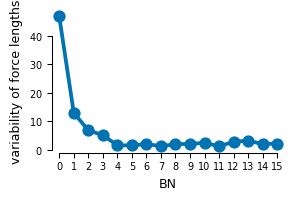

In [154]:
force_length_trends = []
for block, blockdata in data.groupby('block'):
    forces = np.array(blockdata['force_vector'].tolist())
    force_lenghts = np.linalg.norm(forces, axis=1)
    var = np.std(force_lenghts)

    force_length_trends.append({
        'BN': block,
        'var': var
    })
force_length_trends = pd.DataFrame(force_length_trends)
sns.pointplot(data=force_length_trends, x='BN', y='var')
plt.ylabel('variability of force lengths')
sns.despine(trim=True)


<Axes: >

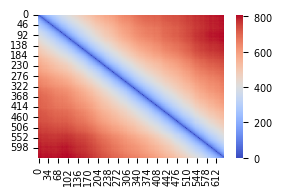

In [27]:
X = data_damped
distances = np.linalg.norm((X[np.newaxis, :, :] - X[:, np.newaxis, :]), axis=-1)  # shape (n, n)
sns.heatmap(distances, cmap='coolwarm')

<Axes: >

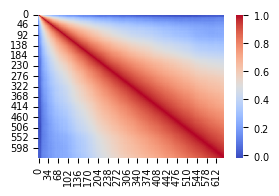

In [28]:
cosine_sims = X @ X.T / (np.linalg.norm(X, axis=1, keepdims=True) @ np.linalg.norm(X, axis=1, keepdims=True).T)
sns.heatmap(cosine_sims, cmap='coolwarm')

In [164]:
block_sum_zones = np.array([135.45454545, 121.72727273, 116.36363636,  94.18181818,  81.72727273,
  97.90909091,  97.54545455,  77.90909091,  97.54545455,  95.18181818,
  76.        ,  82.18181818,  90.90909091,  86.27272727,  81.18181818,
  75.45454545])

In [261]:
# random walk noise dependent on zones
def random_walk_damped_with_zones(D, n_steps, alpha, block_sum_zones, n_trials_per_block=40, step_scale=1.0, init = None):
    steps = np.empty((n_steps, D))
    for block, sum_zones in enumerate(block_sum_zones):
        block_steps = np.random.randn(n_trials_per_block, D) / (1 + sum_zones / 100) * step_scale  # scale noise by sum of zones
        steps[block * n_trials_per_block:(block + 1) * n_trials_per_block] = block_steps
    X = np.empty((n_steps, D))
    if init is not None:
        X[0] = init
    else:
        X[0] = steps[0]
    for t in range(1, n_steps):
        X[t] = alpha * X[t-1] + steps[t]
    return X



In [262]:
data_damped_with_zones = random_walk_damped_with_zones(D, n_steps, alpha=0.99, block_sum_zones=block_sum_zones, n_trials_per_block=n_trials_per_block, step_scale=0.5, init = np.ones(D) * 1)

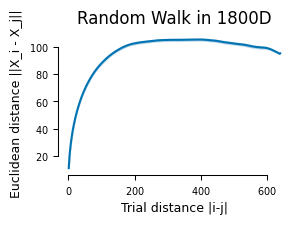

In [263]:
data = pd.DataFrame(data_damped_with_zones, columns=[f'Force{i+1}' for i in range(data_damped_with_zones.shape[1])])
data['N'] = np.arange(n_steps)
X = data.to_numpy()[:,:-1]
trials = data['N'].to_numpy()
n = len(trials)
i,j = np.triu_indices(n, k=1)
# calculate pairwise distances
distances = np.linalg.norm(X[i] - X[j], axis=1)
trial_distances = np.abs(trials[i] - trials[j])
df = pd.DataFrame({'trial1': trials[i], 'trial2': trials[j], 'distance': distances, 'trial_distance': trial_distances})

sns.lineplot(data=df, x='trial_distance', y='distance')
plt.xlabel('Trial distance |i-j|')
plt.ylabel('Euclidean distance ||X_i - X_j||')
plt.title('Random Walk in 1800D')
sns.despine(trim=True)
# plt.savefig('random_walk_damped_1800D.pdf', dpi=300, bbox_inches='tight')


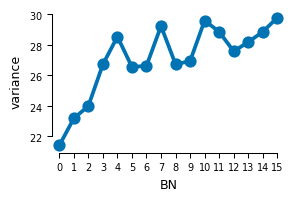

In [264]:
alpha = 0.99
step_scale = 0.5
init = np.ones(D) * 0.1

n_sims = 50
n_trials_per_block = 40
n_blocks = n_steps // n_trials_per_block
all_data = []
for sim in range(n_sims):
    data_damped = random_walk_damped_with_zones(D, n_steps, alpha = alpha, block_sum_zones=block_sum_zones, n_trials_per_block=n_trials_per_block, step_scale=step_scale, init = init)
    data = pd.DataFrame(data_damped, columns=[f'Force{i+1}' for i in range(data_damped.shape[1])])
    blocks = np.repeat(np.arange(n_blocks), n_trials_per_block)
    if len(blocks) < n_steps:
        blocks = np.append(blocks, np.full(n_steps - len(blocks), n_blocks))
    data['block'] = blocks
    data['sim'] = sim
    all_data.append(data)
data = pd.concat(all_data, ignore_index=True)


data['force_vector'] = data[[f'Force{i+1}' for i in range(D)]].values.tolist()

variability_trends = []
for sim, simdata in data.groupby('sim'):
     for block, blockdata in simdata.groupby('block'):
        forces = np.array(blockdata['force_vector'].tolist())
        mean_force = np.mean(forces, axis=0)
        var = np.sqrt(((forces - mean_force) ** 2).sum(axis = 1).mean())
        variability_trends.append({
            'BN': block,
            'variance': var,
            'sim': sim
        })
variability_trends = pd.DataFrame(variability_trends)
sns.pointplot(data=variability_trends, x='BN', y='variance')
sns.despine(trim=True)
# plt.savefig('random_walk_with_zones_variability_trend.pdf', dpi=300, bbox_inches='tight')
    


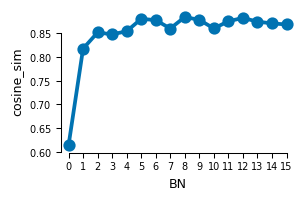

In [179]:
cos_sim_trends = []
for sim, simdata in data.groupby('sim'):
    for block, blockdata in simdata.groupby('block'):
        forces = np.array(blockdata['force_vector'].tolist())
        cosine_sims = forces @ forces.T / (np.linalg.norm(forces, axis=1, keepdims=True) @ np.linalg.norm(forces, axis=1, keepdims=True).T)
        i,j = np.triu_indices(cosine_sims.shape[0], k=1)
        sims = cosine_sims[i,j]
        mean_sims = np.mean(sims)
        cos_sim_trends.append({
            'BN': block,
            'cosine_sim': mean_sims
        })
cos_sim_trends = pd.DataFrame(cos_sim_trends)
sns.pointplot(data=cos_sim_trends, x='BN', y='cosine_sim')
sns.despine(trim=True)


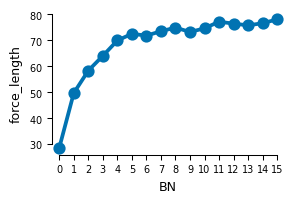

In [183]:
force_length_trends = []
for sim, simdata in data.groupby('sim'):
     for block, blockdata in simdata.groupby('block'):
        forces = np.array(blockdata['force_vector'].tolist())
        forces_mean = np.mean(forces, axis=0)

        force_length_trends.append({
            'BN': block,
            'force_length': np.linalg.norm(forces_mean)
        })
force_length_trends = pd.DataFrame(force_length_trends)
sns.pointplot(data=force_length_trends, x='BN', y='force_length')
sns.despine(trim=True)
plt.savefig('random_walk_with_zones_force_length_trend.pdf', dpi=300, bbox_inches='tight')

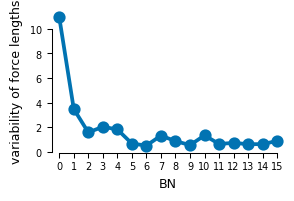

In [265]:
force_length_trends = []
for sim, simdata in data.groupby('sim'):
    for block, blockdata in simdata.groupby('block'):
        forces = np.array(blockdata['force_vector'].tolist())
        force_lengths = np.linalg.norm(forces, axis=1)
        var = np.std(force_lengths)

        force_length_trends.append({
            'BN': block,
            'var': var
        })
force_length_trends = pd.DataFrame(force_length_trends)
sns.pointplot(data=force_length_trends, x='BN', y='var')
plt.ylabel('variability of force lengths')
sns.despine(trim=True)
# plt.savefig('random_walk_with_zones_variability_of_force_lengths_trend.pdf', dpi=300, bbox_inches='tight')

In [ ]:
# random walk damping dependent on zones
def random_walk_damped_with_zones(D, n_steps, alpha, block_sum_zones, n_trials_per_block=40, step_scale=1.0, init = None):
    steps = np.random.randn(n_steps, D) * step_scale
    X = np.empty((n_steps, D))
    if init is not None:
        X[0] = init
    else:
        X[0] = steps[0]

    for t in range(1, n_steps):
        block = t // n_trials_per_block
        sum_zones = block_sum_zones[block]
        X[t] = alpha ** (1 + sum_zones / 100) * X[t-1] + steps[t]
        # X[t] = alpha ** (1/(1 + sum_zones / 100)) * X[t-1] + steps[t]

    return X


In [285]:
alpha = 0.9
step_scale = 0.5
init = np.ones(D) * 0.1

n_sims = 50
n_trials_per_block = 40
n_blocks = n_steps // n_trials_per_block
all_data = []
for sim in range(n_sims):
    data_damped = random_walk_damped_with_zones(D, n_steps, alpha = alpha, block_sum_zones=block_sum_zones, n_trials_per_block=n_trials_per_block, step_scale=step_scale, init = init)
    data = pd.DataFrame(data_damped, columns=[f'Force{i+1}' for i in range(data_damped.shape[1])])
    blocks = np.repeat(np.arange(n_blocks), n_trials_per_block)
    if len(blocks) < n_steps:
        blocks = np.append(blocks, np.full(n_steps - len(blocks), n_blocks))
    data['block'] = blocks
    data['sim'] = sim
    all_data.append(data)
data = pd.concat(all_data, ignore_index=True)


data['force_vector'] = data[[f'Force{i+1}' for i in range(D)]].values.tolist()

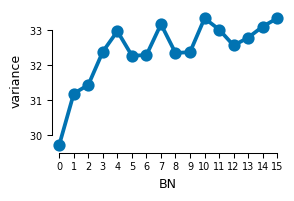

In [287]:
variability_trends = []
for sim, simdata in data.groupby('sim'):
     for block, blockdata in simdata.groupby('block'):
        forces = np.array(blockdata['force_vector'].tolist())
        mean_force = np.mean(forces, axis=0)
        var = np.sqrt(((forces - mean_force) ** 2).sum(axis = 1).mean())
        variability_trends.append({
            'BN': block,
            'variance': var,
            'sim': sim
        })
variability_trends = pd.DataFrame(variability_trends)
sns.pointplot(data=variability_trends, x='BN', y='variance')
sns.despine(trim=True)
# plt.savefig('random_walk_with_zones_variability_trend.pdf', dpi=300, bbox_inches='tight')
    


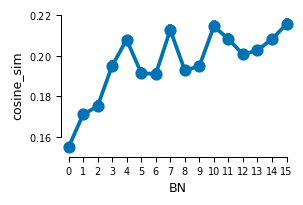

In [288]:
cos_sim_trends = []
for sim, simdata in data.groupby('sim'):
    for block, blockdata in simdata.groupby('block'):
        forces = np.array(blockdata['force_vector'].tolist())
        cosine_sims = forces @ forces.T / (np.linalg.norm(forces, axis=1, keepdims=True) @ np.linalg.norm(forces, axis=1, keepdims=True).T)
        i,j = np.triu_indices(cosine_sims.shape[0], k=1)
        sims = cosine_sims[i,j]
        mean_sims = np.mean(sims)
        cos_sim_trends.append({
            'BN': block,
            'cosine_sim': mean_sims
        })
cos_sim_trends = pd.DataFrame(cos_sim_trends)
sns.pointplot(data=cos_sim_trends, x='BN', y='cosine_sim')
sns.despine(trim=True)


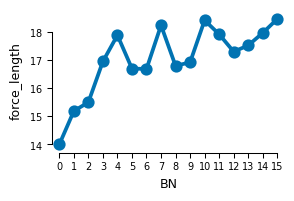

In [289]:
force_length_trends = []
for sim, simdata in data.groupby('sim'):
     for block, blockdata in simdata.groupby('block'):
        forces = np.array(blockdata['force_vector'].tolist())
        forces_mean = np.mean(forces, axis=0)

        force_length_trends.append({
            'BN': block,
            'force_length': np.linalg.norm(forces_mean)
        })
force_length_trends = pd.DataFrame(force_length_trends)
sns.pointplot(data=force_length_trends, x='BN', y='force_length')
sns.despine(trim=True)
# plt.savefig('random_walk_with_zones_force_length_trend.pdf', dpi=300, bbox_inches='tight')

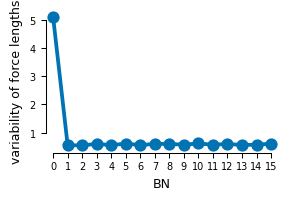

In [290]:
force_length_trends = []
for sim, simdata in data.groupby('sim'):
    for block, blockdata in simdata.groupby('block'):
        forces = np.array(blockdata['force_vector'].tolist())
        force_lengths = np.linalg.norm(forces, axis=1)
        var = np.std(force_lengths)

        force_length_trends.append({
            'BN': block,
            'var': var
        })
force_length_trends = pd.DataFrame(force_length_trends)
sns.pointplot(data=force_length_trends, x='BN', y='var')
plt.ylabel('variability of force lengths')
sns.despine(trim=True)
# plt.savefig('random_walk_with_zones_variability_of_force_lengths_trend.pdf', dpi=300, bbox_inches='tight')

In [303]:
# random walk noise covariance dependent on zones
def random_walk_damped_with_zones(D, n_steps, alpha, block_sum_zones, n_trials_per_block=40, step_scale=1.0, init = None):
    # steps = np.random.randn(n_steps, D) * step_scale
    X = np.empty((n_steps, D))
    if init is not None:
        X[0] = init
    # else:
    #     X[0] = steps[0]

    for t in range(1, n_steps):
        block = t // n_trials_per_block
        sum_zones = block_sum_zones[block]
        # noise covariances high when sum of zones is high
        cov = np.eye(D) + (np.ones((D, D)) * (sum_zones / 1000)) - np.eye(D) * (sum_zones / 1000)
        cov_trace = np.trace(cov)
        eye_trace = np.trace(np.eye(D))
        cov = cov * (eye_trace / cov_trace)  # normalize covariance to have same
        step = np.random.multivariate_normal(np.zeros(D), cov) * step_scale
        X[t] = alpha * X[t-1] + step

    return X
